In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
import math
import random
from random import uniform
from sklearn import preprocessing
from sklearn import tree
import skimage.io

# Exercise 1 : simple dataset with 2 features (same as previous TP)

## Load the data

In [42]:
# We will load the data that is in the file 'donnees_exo1.txt'
data = pd.read_csv('donnees_exo1.txt', sep = ' ')
data

,X1,X2,Y
0,-0.697580,0.684940,0
1,-0.478690,0.633770,1
2,0.057028,0.918860,0
3,-0.593890,0.494880,0
4,0.229840,-0.411550,1
...,...,...,...
113,0.460250,0.012427,1
114,-0.046659,0.816520,1
115,0.322000,0.692250,1
116,-0.524770,0.209800,1


## Train / Valid / Test split

In [43]:
data_train, data_test = train_test_split(data, test_size = 0.3, random_state = 4)
data_valid, data_test = train_test_split(data_test, test_size = 0.5, random_state = 4)
# 82 examples in train, 18 in valid and 18 in test

## Plotting the training set

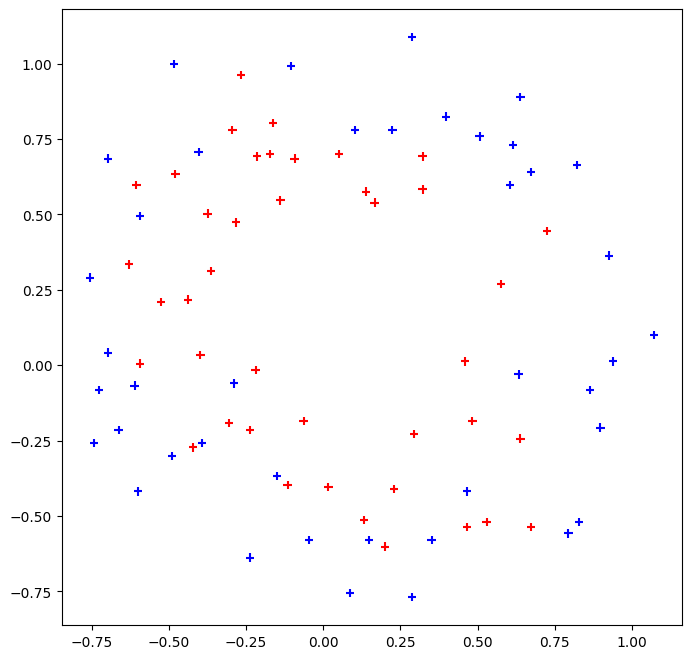

In [44]:
color_map = matplotlib.colors.ListedColormap(pd.Series(['blue', 'red']))
fig = plt.figure(figsize=  (8,8))
fig = plt.scatter(data_train.iloc[:,0], data_train.iloc[:,1], c = data_train.Y, cmap = color_map, marker='+')

## Fitting a decision tree

In [45]:
# The basic decision tree can be obtained easily by this command
dt = tree.DecisionTreeClassifier().fit(data_train.iloc[:,:2],data_train.Y)
# More advanced options can be inserted into the 'DecisionTreeClassifier' function (we will see some later)
# The 'fit' function needs to have 2 parameters (at least) : 
# - the set of features describing the examples (here the 2 first columns of our train set)
# - the associated labels (classes, here the column 'Y' of our train set)


## Visualizing the obtained tree

[Text(0.6071428571428571, 0.9545454545454546, 'x[0] <= 0.76\ngini = 0.5\nsamples = 82\nvalue = [41, 41]'),
 Text(0.5595238095238095, 0.8636363636363636, 'x[0] <= -0.646\ngini = 0.494\nsamples = 74\nvalue = [33, 41]'),
 Text(0.5833333333333333, 0.9090909090909092, 'True  '),
 Text(0.5119047619047619, 0.7727272727272727, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.6071428571428571, 0.7727272727272727, 'x[1] <= 0.703\ngini = 0.479\nsamples = 68\nvalue = [27, 41]'),
 Text(0.30952380952380953, 0.6818181818181818, 'x[1] <= -0.558\ngini = 0.427\nsamples = 55\nvalue = [17, 38]'),
 Text(0.09523809523809523, 0.5909090909090909, 'x[0] <= 0.175\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.047619047619047616, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.14285714285714285, 0.5, 'x[0] <= 0.244\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.09523809523809523, 0.4090909090909091, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.19047619047619047, 0.409090909090909

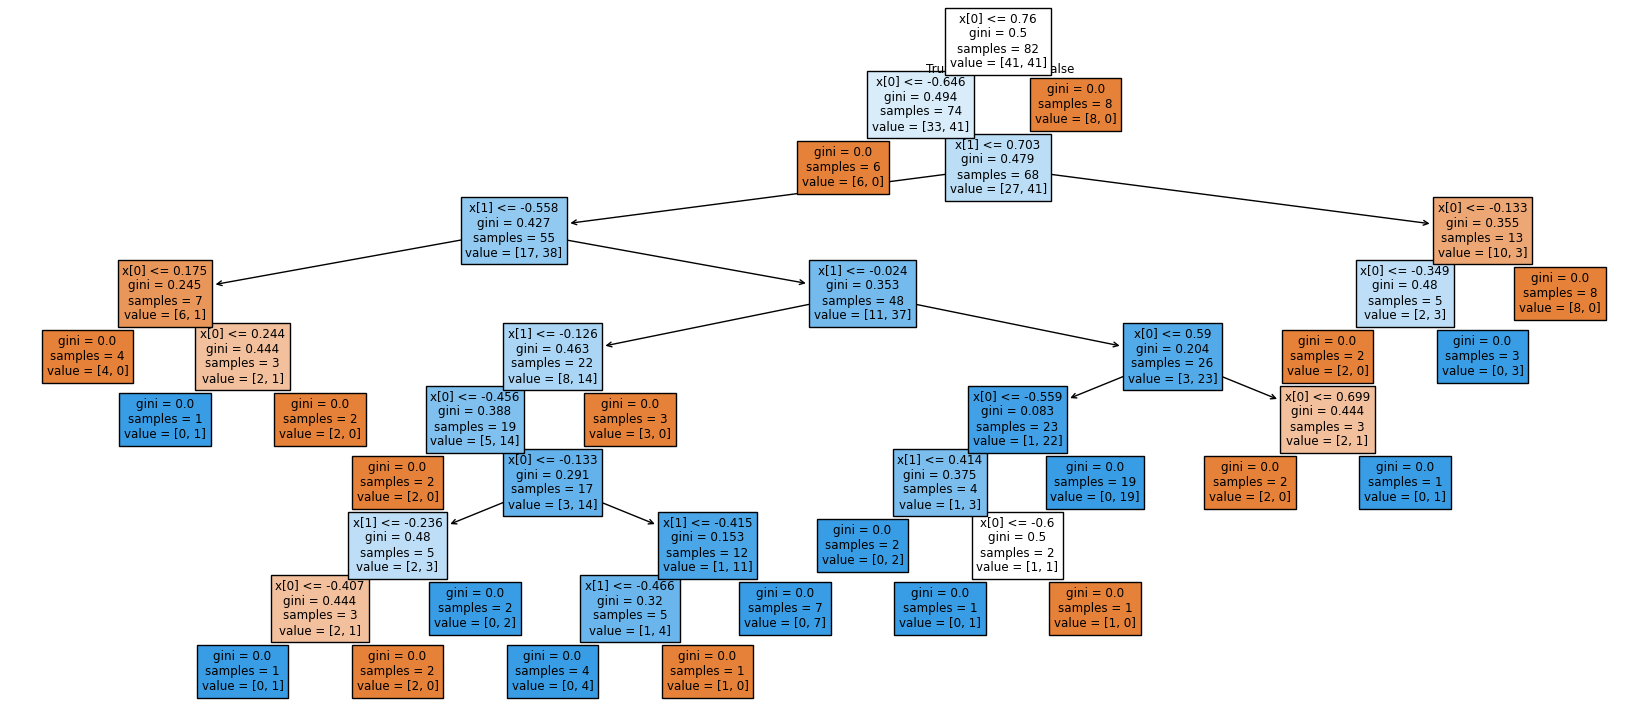

In [46]:
plt.figure(figsize=(21, 9))
tree.plot_tree(dt, filled=True)
# The 'plot_tree' function outputs two things : 
# - a text version of the tree (where are written the informations about all the nodes of the tree)
# - a graphical representation of the tree (right branches correspond to answer 'no' and left branches 'yes')

In [47]:
print("First training example:")
print(data_train.iloc[0])
print("Prediction:", dt.predict(data_train.iloc[0:1, 0:2])[0])
# Features X1 ≈ -0.663, X2 ≈ -0.214, class Y = 0.
# The tree sends it to a pure leaf of class 0, so the prediction is correct.
# Normal: an unpruned tree memorizes the training set.

First training example:
X1   -0.66302
X2   -0.21418
Y     0.00000
Name: 98, dtype: float64
Prediction: 0


In [48]:
# We can obtain automatically the prediction of the tree for any example with the 'predict' command (as for logistic regression):
dt.predict(data_train.iloc[:1,:2]) # here I ask to predict the first example of the train set, need to give its features

array([0])

In [49]:
print("Training accuracy:", dt.score(data_train.iloc[:, 0:2], data_train.Y))
# 1.0: every training point ends in a pure leaf of its true class.

Training accuracy: 1.0


In [50]:
print("Validation accuracy:", dt.score(data_valid.iloc[:, 0:2], data_valid.Y))
print("ANSWER: training accuracy = 1.0 (pure leaves). Validation is lower (~0.83): the unpruned tree overfits.")

Validation accuracy: 0.8333333333333334
ANSWER: training accuracy = 1.0 (pure leaves). Validation is lower (~0.83): the unpruned tree overfits.


In [51]:
def draw_boundary_tree(model, data, x_min, x_max, y_min, y_max):
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    zz = np.c_[xx.ravel(), yy.ravel()]
    zz = pd.DataFrame(zz)
    zz2 = zz
    pred_zz= pd.Series(model.predict(zz2))
    color_map = matplotlib.colors.ListedColormap(pd.Series(['blue', 'red']))
    fig = plt.figure(figsize=  (8,8))
    fig = plt.scatter(zz.iloc[:,0], zz.iloc[:,1], c = pred_zz, cmap = color_map, marker='+')
    fig = plt.scatter(data.iloc[:,0], data.iloc[:,1], s = 50, c = data.iloc[:,2], cmap = color_map)

/Users/ardjood/jupyter_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


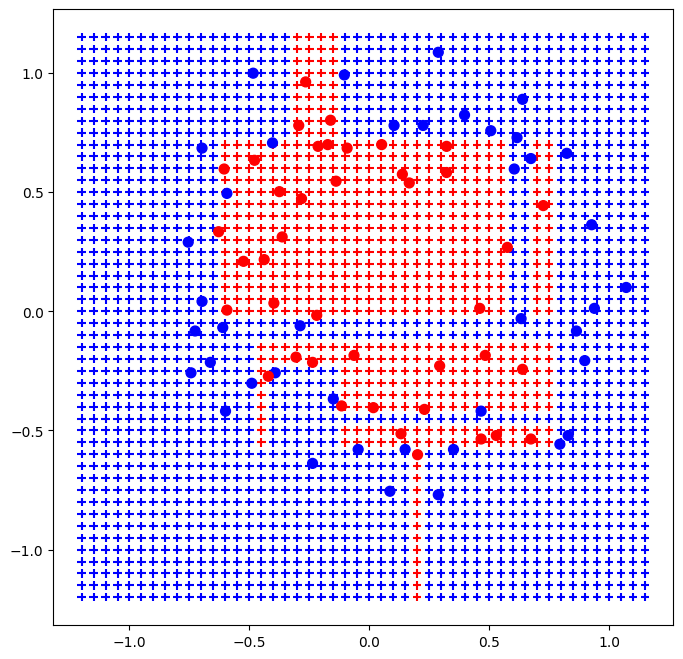

In [52]:
draw_boundary_tree(dt, data_train, -1.2, 1.2, -1.2, 1.2)

## Pruning the tree

In [53]:
clf = tree.DecisionTreeClassifier() # first declare a tree
path = clf.cost_complexity_pruning_path(data_train.iloc[:,0:2], data_train.Y) # then ask for all the possible values 
# of alpha to prune this tree (depends on the training set)
path

{'ccp_alphas': array([0.        , 0.0077766 , 0.01045296, 0.01117886, 0.01263351,
        0.01626016, 0.02513799, 0.02727425, 0.02814259, 0.05398197,
        0.05405405]),
 'impurities': array([0.        , 0.0233298 , 0.04423572, 0.06659345, 0.10449397,
        0.12075413, 0.14589213, 0.22771487, 0.28400004, 0.44594595,
        0.5       ])}

Text(0, 0.5, 'total impurity of leaves')

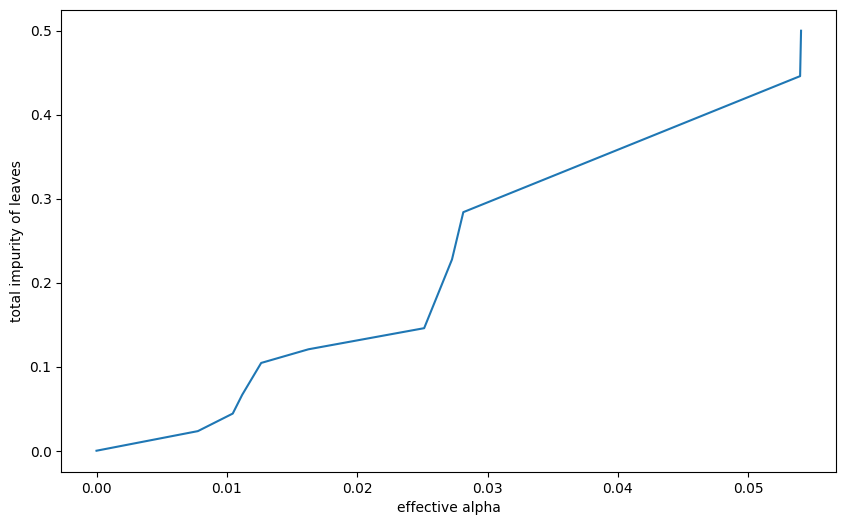

In [54]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, impurities)
plt.xlabel("effective alpha")
plt.ylabel("total impurity of leaves")

In [55]:
dt_pruned = tree.DecisionTreeClassifier(ccp_alpha=path.ccp_alphas[2]).fit(data_train.iloc[:,0:2], data_train.Y)
# Here I asked for the third value from all the possible alpha (the first one is 0, already done with the basic tree)

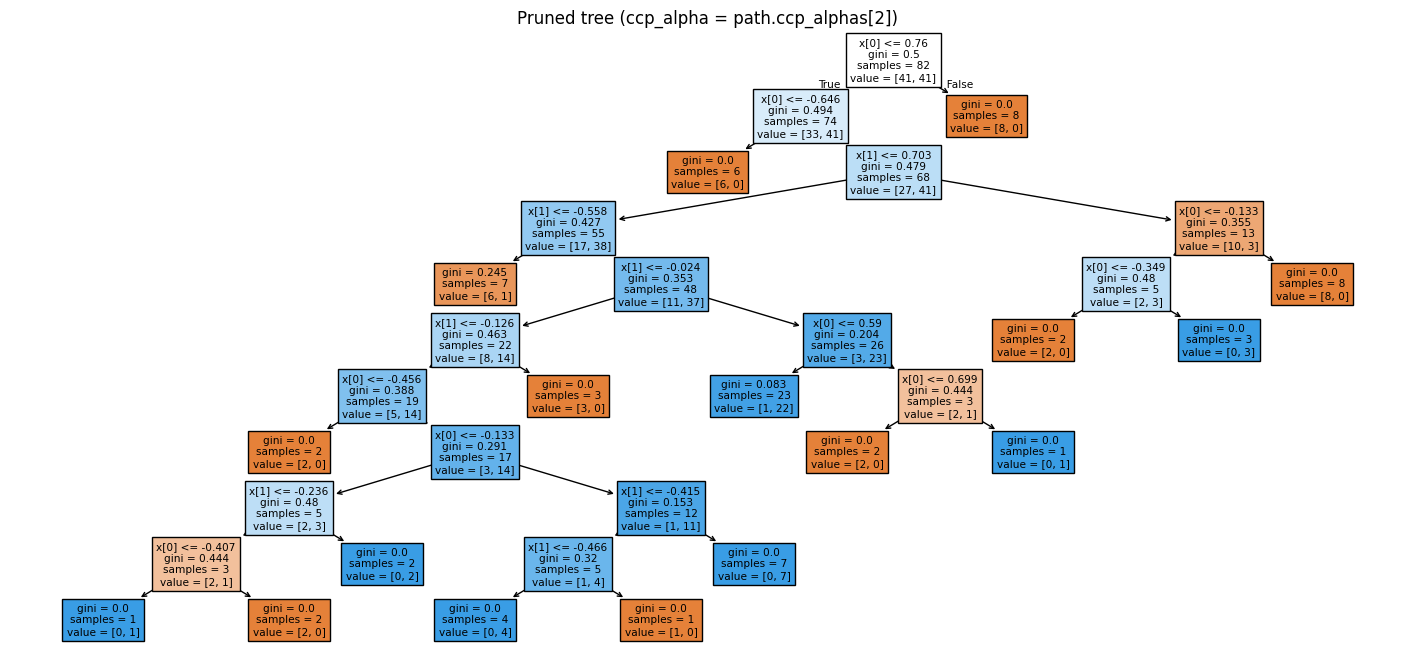

In [56]:
plt.figure(figsize=(18, 8))
tree.plot_tree(dt_pruned, filled=True)
plt.title("Pruned tree (ccp_alpha = path.ccp_alphas[2])")
plt.show()

/Users/ardjood/jupyter_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


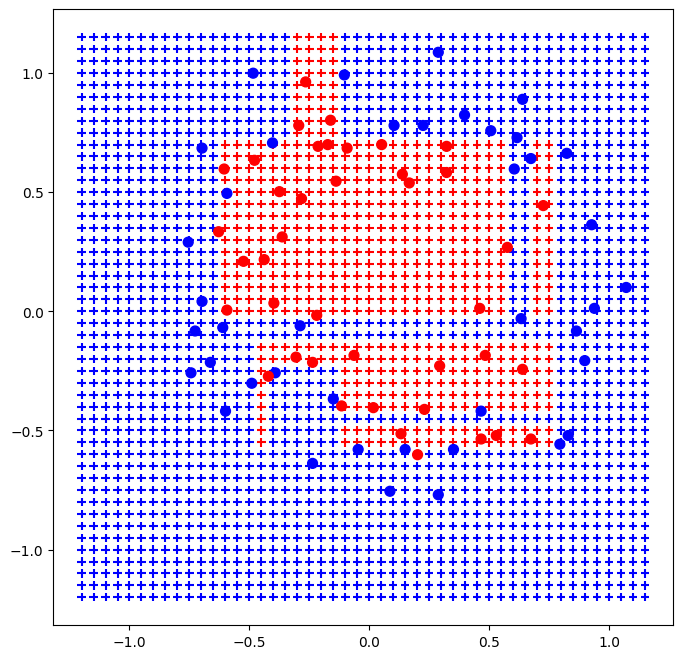

In [57]:
draw_boundary_tree(dt_pruned, data_train, -1.2, 1.2, -1.2, 1.2)

In [58]:
print("Train (pruned):", dt_pruned.score(data_train.iloc[:, 0:2], data_train.Y))
print("Validation (pruned):", dt_pruned.score(data_valid.iloc[:, 0:2], data_valid.Y))

Train (pruned): 0.975609756097561
Validation (pruned): 0.8333333333333334


In [59]:
# Compared with alpha=0: fewer nodes, some impure leaves, a simpler boundary.

alpha=0.000000  train=1.0000  val=0.8333  leaves=22
alpha=0.007777  train=0.9878  val=0.8333  leaves=19
alpha=0.010453  train=0.9756  val=0.8333  leaves=17
alpha=0.011179  train=0.9634  val=0.8333  leaves=15
alpha=0.012634  train=0.9390  val=0.8889  leaves=12
alpha=0.016260  train=0.9268  val=0.8889  leaves=11
alpha=0.025138  train=0.9146  val=0.8889  leaves=10
alpha=0.027274  train=0.8537  val=0.8889  leaves=7
alpha=0.028143  train=0.8171  val=0.8889  leaves=5
alpha=0.053982  train=0.5976  val=0.5000  leaves=2
alpha=0.054054  train=0.5000  val=0.6667  leaves=1


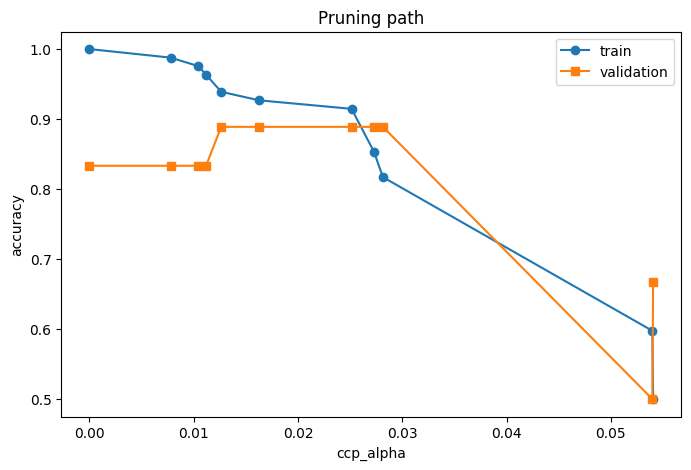

In [60]:
train_scores = []
valid_scores = []
for alpha in path.ccp_alphas:
    model = tree.DecisionTreeClassifier(ccp_alpha=alpha).fit(data_train.iloc[:, 0:2], data_train.Y)
    train_scores.append(model.score(data_train.iloc[:, 0:2], data_train.Y))
    valid_scores.append(model.score(data_valid.iloc[:, 0:2], data_valid.Y))
    print(f"alpha={alpha:.6f}  train={train_scores[-1]:.4f}  val={valid_scores[-1]:.4f}  leaves={model.get_n_leaves()}")

plt.figure(figsize=(8, 5))
plt.plot(path.ccp_alphas, train_scores, marker="o", label="train")
plt.plot(path.ccp_alphas, valid_scores, marker="s", label="validation")
plt.xlabel("ccp_alpha")
plt.ylabel("accuracy")
plt.legend()
plt.title("Pruning path")
plt.show()

/Users/ardjood/jupyter_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Selected alpha: 0.028142589118198877
Leaves: 5
Train: 0.8170731707317073
Validation: 0.8888888888888888


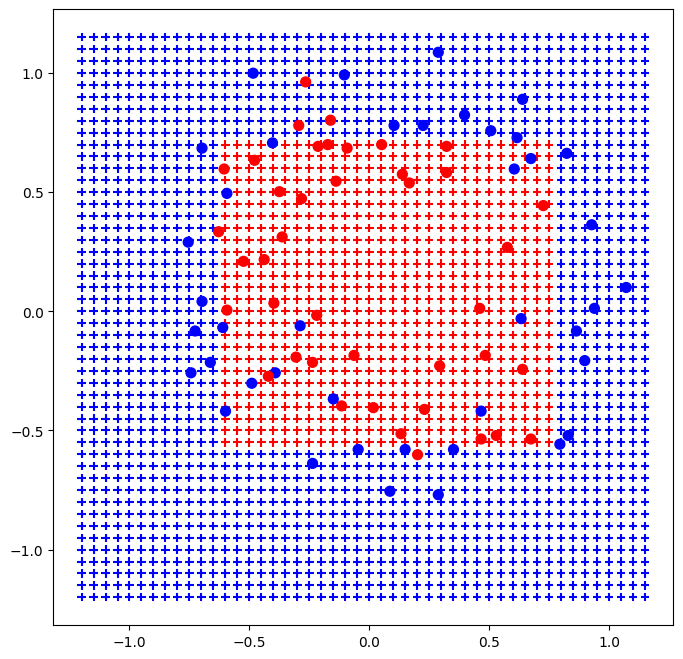

In [61]:
# Among alphas with the best validation score, take the most pruned tree (largest alpha).
best_val = max(valid_scores)
candidates = [a for a, s in zip(path.ccp_alphas, valid_scores) if s == best_val]
best_alpha = max(candidates)
dt_best = tree.DecisionTreeClassifier(ccp_alpha=best_alpha).fit(data_train.iloc[:, 0:2], data_train.Y)
print("Selected alpha:", best_alpha)
print("Leaves:", dt_best.get_n_leaves())
print("Train:", dt_best.score(data_train.iloc[:, 0:2], data_train.Y))
print("Validation:", dt_best.score(data_valid.iloc[:, 0:2], data_valid.Y))
draw_boundary_tree(dt_best, data_train, -1.2, 1.2, -1.2, 1.2)

In [62]:
gen_acc = dt_best.score(data_test.iloc[:, 0:2], data_test.Y)
print("Test accuracy:", gen_acc)
print("Estimated generalization error:", 1 - gen_acc)

Test accuracy: 0.7777777777777778
Estimated generalization error: 0.2222222222222222


In [63]:
print("""ANSWER: among alphas with the best validation score, keep the most pruned tree (largest alpha).
Selected alpha ≈ 0.028, 5 leaves, test accuracy ≈ 0.78, gen. error ≈ 0.22.
The unpruned tree overfits; moderate pruning keeps a circular-enough staircase.""")

ANSWER: among alphas with the best validation score, keep the most pruned tree (largest alpha).
Selected alpha ≈ 0.028, 5 leaves, test accuracy ≈ 0.78, gen. error ≈ 0.22.
The unpruned tree overfits; moderate pruning keeps a circular-enough staircase.


# Exercise 2 : with a real dataset of handwritten digits

In [64]:
mnist = pd.read_csv('cp_sample.csv', sep=';')
mnist.shape

(1000, 785)

In [65]:
print(mnist.label.value_counts())

label
2    121
1    113
4    104
3    100
8    100
0     97
7     94
6     91
5     91
9     89
Name: count, dtype: int64


In [66]:
# The values of pixels and label for one image can be obtained by the command:
mnist.iloc[0,:] # First image of the dataset
# You can see that the label is in the column 'label' and the other columns are pixel0, pixel1, etc...
# This first image represents the digit 1

label       1
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Name: 0, Length: 785, dtype: int64

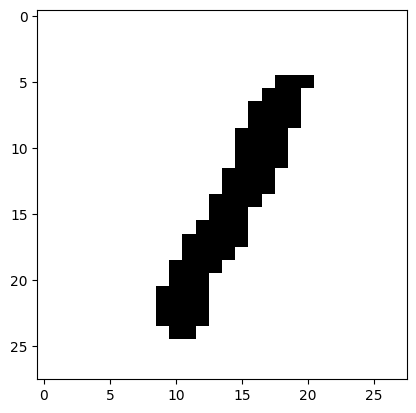

In [67]:
# It is possible to see an image from its pixel values using the following command:
plt.imshow(mnist.iloc[0,1:].to_numpy().reshape(28,28),cmap = 'Greys')
# Here is the first image, representing a 1

In [68]:
# Question : Split this dataset into train / validation / test sets


In [69]:
data_train, data_test = train_test_split(mnist, test_size=0.3, random_state=4)
data_valid, data_test = train_test_split(data_test, test_size=0.5, random_state=4)
print(data_train.shape, data_valid.shape, data_test.shape)

(700, 785) (150, 785) (150, 785)


In [70]:
dt = tree.DecisionTreeClassifier(random_state=4).fit(data_train.iloc[:, 1:], data_train.label)

In [71]:
print("Train:", dt.score(data_train.iloc[:, 1:], data_train.label))
print("Validation:", dt.score(data_valid.iloc[:, 1:], data_valid.label))

Train: 1.0
Validation: 0.6333333333333333


In [72]:
print("ANSWER: Train = 1.0 (pure leaves). Validation is much lower: the tree overfits the pixels.")

ANSWER: Train = 1.0 (pure leaves). Validation is much lower: the tree overfits the pixels.


In [73]:
clf = tree.DecisionTreeClassifier(random_state=4)
path = clf.cost_complexity_pruning_path(data_train.iloc[:, 1:], data_train.label)
train_scores, valid_scores = [], []
for alpha in path.ccp_alphas:
    model = tree.DecisionTreeClassifier(ccp_alpha=alpha, random_state=4).fit(data_train.iloc[:, 1:], data_train.label)
    train_scores.append(model.score(data_train.iloc[:, 1:], data_train.label))
    valid_scores.append(model.score(data_valid.iloc[:, 1:], data_valid.label))

best_val = max(valid_scores)
best_alpha = max(a for a, s in zip(path.ccp_alphas, valid_scores) if s == best_val)
dt_best = tree.DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=4).fit(data_train.iloc[:, 1:], data_train.label)
print("Selected alpha:", best_alpha)
print("Train:", dt_best.score(data_train.iloc[:, 1:], data_train.label))
print("Validation:", dt_best.score(data_valid.iloc[:, 1:], data_valid.label))

Selected alpha: 0.002803234501347706
Train: 0.8757142857142857
Validation: 0.6466666666666666


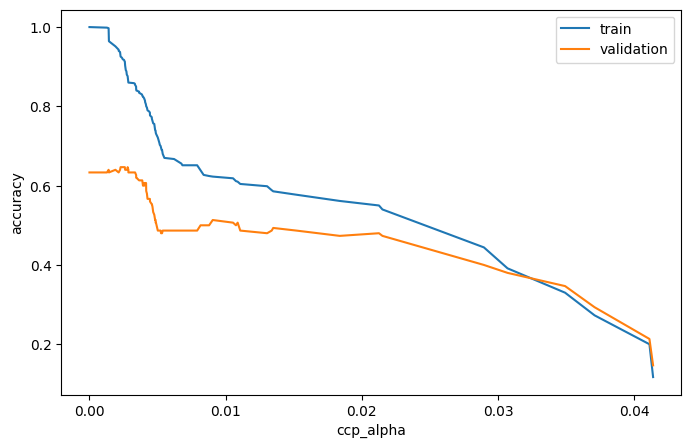

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(path.ccp_alphas, train_scores, label="train")
plt.plot(path.ccp_alphas, valid_scores, label="validation")
plt.xlabel("ccp_alpha")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [75]:
gen_acc = dt_best.score(data_test.iloc[:, 1:], data_test.label)
print("Test accuracy:", gen_acc)
print("Estimated generalization error:", 1 - gen_acc)

Test accuracy: 0.58
Estimated generalization error: 0.42000000000000004


In [76]:
print("ANSWER: pruning helps a little, but a single tree on raw pixels stays weak (test ≈ 0.58).")

ANSWER: pruning helps a little, but a single tree on raw pixels stays weak (test ≈ 0.58).


## Trying the model on your own written image 

In [77]:

def read_myimage(f):
    myimage = skimage.io.imread(f, as_gray=True)
    i0 = np.where(myimage==0)
    i1 = np.where(myimage == 1)
    myimage[i0] = 1
    myimage[i1] = 0
    plt.imshow(myimage, cmap='Greys')
    return myimage.reshape(1,28*28)

In [78]:
import os
if os.path.exists("test_0.png"):
    myim = read_myimage("test_0.png")
    print(dt.predict(myim))
else:
    print("test_0.png is not in the folder; draw a 28x28 digit to try this cell.")


test_0.png is not in the folder; draw a 28x28 digit to try this cell.


## Logistic regression for the same task

In [79]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000).fit(data_train.iloc[:, 1:], data_train.label)
print("Train:", lr.score(data_train.iloc[:, 1:], data_train.label))
print("Validation:", lr.score(data_valid.iloc[:, 1:], data_valid.label))
print("Test:", lr.score(data_test.iloc[:, 1:], data_test.label))
print("Estimated generalization error:", 1 - lr.score(data_test.iloc[:, 1:], data_test.label))

Train: 1.0
Validation: 0.86
Test: 0.8933333333333333
Estimated generalization error: 0.10666666666666669


In [80]:
# Logistic regression on pixels is much better than the tree (test around 0.89).
# Predict test_0.png only if the file is present.
import os
if os.path.exists("test_0.png"):
    print(lr.predict(read_myimage("test_0.png")))
else:
    print("test_0.png not found; skip own-digit prediction.")

test_0.png not found; skip own-digit prediction.


# Using HOG representation rather than pixel values

In [81]:
from skimage.feature import hog

In [82]:
myimage = mnist.iloc[0,1:] # first image of the mnist dataset (784 pixel values)
myimage_hog = hog(myimage.to_numpy().reshape(28,28), orientations=8, pixels_per_cell=(14,14), cells_per_block=(1,1))
myimage_hog

array([0.70710678, 0.        , 0.70710678, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.63453054, 0.        ,
       0.63453054, 0.        , 0.44129581, 0.        , 0.        ,
       0.        , 0.59539679, 0.        , 0.59539679, 0.        ,
       0.23002187, 0.        , 0.48795006, 0.        , 0.70710678,
       0.        , 0.70710678, 0.        , 0.        , 0.        ,
       0.        , 0.        ])

In [83]:
def my_hog(row, ori, cell):
    img = row.iloc[1:].to_numpy().reshape(28, 28)
    return pd.Series(hog(img, orientations=ori, pixels_per_cell=(cell, cell), cells_per_block=(1, 1)))

In [84]:
hog_train = data_train.apply(my_hog, axis=1, args=(8,14))
hog_valid= data_valid.apply(my_hog, axis=1, args=(8,14))
hog_test = data_test.apply(my_hog, axis=1, args=(8,14))
hog_train['label'] = data_train.label
hog_valid['label'] = data_valid.label
hog_test['label'] = data_test.label

In [85]:
hog_train
# you see here that each image of the training set is now a vector of length 32

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,label
715,0.502681,0.0,0.502681,0.0,0.491869,0.0,0.502681,0.0,0.331770,0.0,...,0.0,0.500000,0.0,0.500000,0.0,0.500000,0.0,0.500000,0.0,8
920,0.699372,0.0,0.699372,0.0,0.147506,0.0,0.000000,0.0,0.500000,0.0,...,0.0,0.681478,0.0,0.681478,0.0,0.000000,0.0,0.266785,0.0,9
295,0.465444,0.0,0.618883,0.0,0.618883,0.0,0.131647,0.0,0.500000,0.0,...,0.0,0.307510,0.0,0.543607,0.0,0.552236,0.0,0.552236,0.0,2
83,0.517744,0.0,0.517744,0.0,0.517744,0.0,0.442518,0.0,0.568812,0.0,...,0.0,0.577350,0.0,0.577350,0.0,0.577350,0.0,0.000000,0.0,0
942,0.604642,0.0,0.604642,0.0,0.377247,0.0,0.355672,0.0,0.603838,0.0,...,0.0,0.577350,0.0,0.577350,0.0,0.577350,0.0,0.000000,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,0.577350,0.0,0.577350,0.0,0.577350,0.0,0.000000,0.0,0.555912,0.0,...,0.0,0.572579,0.0,0.572579,0.0,0.572579,0.0,0.128290,0.0,0
709,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.000000,0.0,0.615943,0.0,...,0.0,0.656532,0.0,0.754298,0.0,0.000000,0.0,0.000000,0.0,1
439,0.707107,0.0,0.707107,0.0,0.000000,0.0,0.000000,0.0,0.566947,0.0,...,0.0,0.558947,0.0,0.558947,0.0,0.558947,0.0,0.250470,0.0,0
174,0.500000,0.0,0.500000,0.0,0.500000,0.0,0.500000,0.0,0.197028,0.0,...,0.0,0.500000,0.0,0.500000,0.0,0.500000,0.0,0.500000,0.0,5


In [86]:
def select_tree(Xtr, ytr, Xva, yva, Xte, yte):
    path = tree.DecisionTreeClassifier(random_state=4).cost_complexity_pruning_path(Xtr, ytr)
    val_scores = []
    for alpha in path.ccp_alphas:
        model = tree.DecisionTreeClassifier(ccp_alpha=alpha, random_state=4).fit(Xtr, ytr)
        val_scores.append(model.score(Xva, yva))
    best_val = max(val_scores)
    best_alpha = max(a for a, s in zip(path.ccp_alphas, val_scores) if s == best_val)
    model = tree.DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=4).fit(Xtr, ytr)
    print("alpha", best_alpha, "train", model.score(Xtr, ytr), "val", model.score(Xva, yva))
    print("test", model.score(Xte, yte), "gen. error", 1 - model.score(Xte, yte))
    return model

print("=== HOG 8 ori, 14x14 ===")
dt_hog = select_tree(
    hog_train.drop(columns="label") if "label" in hog_train.columns else hog_train,
    hog_train["label"] if "label" in hog_train.columns else data_train.label,
    hog_valid.drop(columns="label") if "label" in hog_valid.columns else hog_valid,
    hog_valid["label"] if "label" in hog_valid.columns else data_valid.label,
    hog_test.drop(columns="label") if "label" in hog_test.columns else hog_test,
    hog_test["label"] if "label" in hog_test.columns else data_test.label,
)

=== HOG 8 ori, 14x14 ===
alpha 0.005317847464188931 train 0.7 val 0.58
test 0.6133333333333333 gen. error 0.3866666666666667


In [87]:
print("ANSWER: HOG 14x14 is not better than raw pixels for a tree (too coarse, only 4 blocks).")

ANSWER: HOG 14x14 is not better than raw pixels for a tree (too coarse, only 4 blocks).


In [88]:
# Same selection procedure as above; 14x14 HOG does not beat raw pixels for trees.

In [89]:
print("HOG 14x14 done.")

HOG 14x14 done.


In [90]:
hog_train4 = data_train.apply(my_hog, axis=1, args=(8, 4))
hog_valid4 = data_valid.apply(my_hog, axis=1, args=(8, 4))
hog_test4 = data_test.apply(my_hog, axis=1, args=(8, 4))
print(hog_train4.shape)
print("=== HOG 8 ori, 4x4 ===")
dt_hog4 = select_tree(hog_train4, data_train.label, hog_valid4, data_valid.label, hog_test4, data_test.label)

(700, 392)
=== HOG 8 ori, 4x4 ===
alpha 0.005571428571428571 train 0.8314285714285714 val 0.6333333333333333
test 0.6533333333333333 gen. error 0.3466666666666667


In [91]:
# More blocks keep the digit shape. The tree improves versus 14x14, still weaker than logistic regression.

In [92]:
print("""ANSWER: HOG 8 orientations + 4x4 cells keeps more spatial structure than 14x14.
The pruned tree improves versus coarse HOG / raw pixels, but a tree is still a weak classifier on this digit task.""")

ANSWER: HOG 8 orientations + 4x4 cells keeps more spatial structure than 14x14.
The pruned tree improves versus coarse HOG / raw pixels, but a tree is still a weak classifier on this digit task.


In [93]:
print("""Typical numbers (random_state=4): raw-pixel pruned tree test ≈ 0.58; HOG 4x4 tree is better;
logistic regression on the same HOG is much stronger (test ≈ 0.91).""")

Typical numbers (random_state=4): raw-pixel pruned tree test ≈ 0.58; HOG 4x4 tree is better;
logistic regression on the same HOG is much stronger (test ≈ 0.91).


In [94]:
lr_hog = LogisticRegression(max_iter=2000).fit(hog_train4, data_train.label)
print("Train:", lr_hog.score(hog_train4, data_train.label))
print("Validation:", lr_hog.score(hog_valid4, data_valid.label))
print("Test:", lr_hog.score(hog_test4, data_test.label))
print("Estimated generalization error:", 1 - lr_hog.score(hog_test4, data_test.label))

Train: 0.9985714285714286
Validation: 0.9333333333333333
Test: 0.9066666666666666
Estimated generalization error: 0.09333333333333338


In [97]:
print("""ANSWER / Conclusion:
Logistic regression + fine HOG is the strongest model(test ≈ 0.91).
A tree remains a weak classifier on this image task, even after pruning and HOG.""")

ANSWER / Conclusion:
Logistic regression + fine HOG is the strongest model(test ≈ 0.91).
A tree remains a weak classifier on this image task, even after pruning and HOG.
